# Part 2

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
orders = pd.read_csv("olist_orders_dataset_cleaned.csv")
customers = pd.read_csv("olist_customers_dataset_cleaned.csv")
order_items = pd.read_csv("olist_order_items_dataset_cleaned.csv")
products = pd.read_csv("olist_products_dataset_cleaned.csv")
translation = pd.read_csv("product_category_name_translation.csv")

In [78]:
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

#### ✅ What percentage of orders are delivered late?

In [79]:
# Take only the orders that their status is delivered
fi = orders["order_status"] == "delivered"
delivered = orders[fi]
delivered.shape

(96267, 8)

In [80]:
# I used normlized in order to ignore the time just the date
delivered_day = delivered["order_delivered_customer_date"].dt.normalize()
delivered_day.head()

0   2017-10-10
1   2018-08-07
2   2018-08-17
3   2017-12-02
4   2018-02-16
Name: order_delivered_customer_date, dtype: datetime64[us]

In [81]:
fi1 = delivered_day > delivered["order_estimated_delivery_date"]
fi1.value_counts()

False    89736
True      6531
Name: count, dtype: int64

In [82]:
late_percentage = fi1.mean() * 100
late_percentage

np.float64(6.784256287201222)

#### ✅ Is the delay pattern consistent (e.g., certain months, weekends, or quarters)?

##### By quarter

In [62]:
# Convert the dates to datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [63]:
orders["IS LATE"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
)

In [64]:
orders["QUARTER"] = orders["order_purchase_timestamp"].dt.to_period("Q")

In [65]:
by_quarter = orders.groupby("QUARTER")["IS LATE"].mean() * 100
by_quarter = by_quarter.drop(["2016Q3", "2018Q4"])
by_quarter

QUARTER
2016Q4     0.934579
2017Q1     4.157132
2017Q2     4.600899
2017Q3     3.856509
2017Q4     9.760744
2018Q1    14.188042
2018Q2     5.022119
2018Q3     7.334119
Freq: Q-DEC, Name: IS LATE, dtype: float64

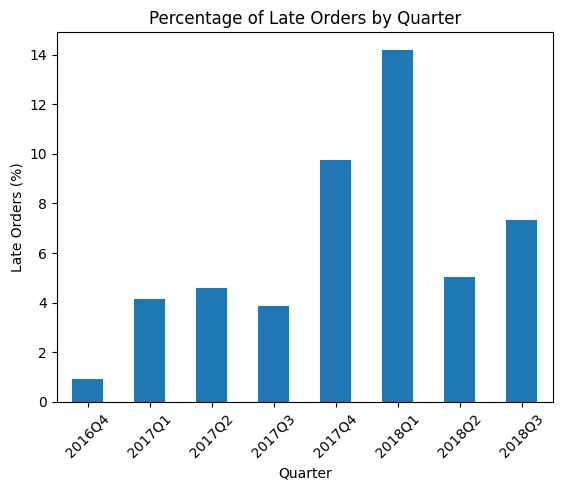

In [66]:
by_quarter.plot(kind="bar")

plt.title("Percentage of Late Orders by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Late Orders (%)")
plt.xticks(rotation=45)
plt.show();

#### ✅ Does lateness occur even when the seller and customer are in the same state?

In [101]:
sellers = pd.read_csv("olist_sellers_dataset_cleaned.csv")

In [102]:
same_state_data = orders.merge(order_items[["order_id", "seller_id"]],on="order_id")
same_state_data = same_state_data.merge(customers[["customer_id", "customer_state"]],on="customer_id")
same_state_data = same_state_data.merge(sellers[["seller_id", "seller_state"]],on="seller_id")

same_state_data["IS LATE"] = (same_state_data["order_delivered_customer_date"] >same_state_data["order_estimated_delivery_date"])

In [103]:
same_state = same_state_data[same_state_data["seller_state"] == same_state_data["customer_state"]]

In [104]:
same_state["IS LATE"].value_counts()

IS LATE
False    38284
True      2382
Name: count, dtype: int64

In [105]:
same_state["IS LATE"].value_counts(normalize=True) * 100

IS LATE
False    94.142527
True      5.857473
Name: proportion, dtype: float64

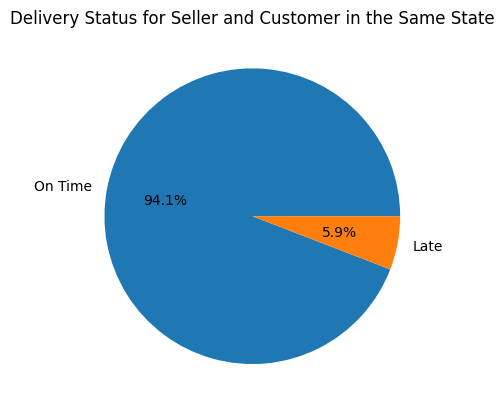

In [106]:
same_state_status = same_state["IS LATE"].value_counts()

same_state_status.index = same_state_status.index.map({
    False: "On Time",
    True: "Late"
})

same_state_status.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Delivery Status for Seller and Customer in the Same State")
plt.ylabel("")
plt.show();

#### ✅ Does order weight, size, or product type influence delivery delays?

##### By weight

In [107]:
delivery_product = orders.merge(order_items[["order_id", "product_id"]],on="order_id")
delivery_product = delivery_product.merge(products,on="product_id")

In [108]:
delivery_product["WEIGHT KG"] = (delivery_product["product_weight_g"] / 1000)

In [109]:
delivery_product["WEIGHT KG"].describe()

count    112367.000000
mean          2.094048
std           3.752490
min           0.000000
25%           0.300000
50%           0.700000
75%           1.800000
max          40.425000
Name: WEIGHT KG, dtype: float64

In [110]:
weight_bins = [0, 5, 15, 25, 45]
weight_labels = ["0-5 kg", "5-15 kg", "15-25 kg", "25-45 kg"]

delivery_product["WEIGHT GROUP"] = pd.cut(delivery_product["WEIGHT KG"],bins=weight_bins, labels=weight_labels)

In [112]:
delivery_product["IS LATE"] = (delivery_product["order_delivered_customer_date"] >
    delivery_product["order_estimated_delivery_date"])

In [113]:
weight_delay = (delivery_product.groupby("WEIGHT GROUP")["IS LATE"].mean() * 100)

weight_delay

WEIGHT GROUP
0-5 kg       7.626628
5-15 kg      8.166985
15-25 kg    10.706751
25-45 kg    12.387387
Name: IS LATE, dtype: float64

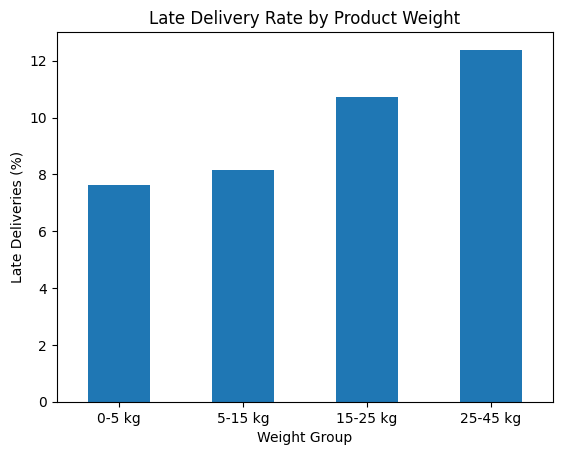

In [114]:
weight_delay.plot(kind="bar")

plt.title("Late Delivery Rate by Product Weight")
plt.xlabel("Weight Group")
plt.ylabel("Late Deliveries (%)")
plt.xticks(rotation=360)
plt.show();

##### By size

In [115]:
delivery_product["VOLUME CM3"] = (delivery_product["product_length_cm"] *
delivery_product["product_width_cm"] * delivery_product["product_height_cm"])

In [116]:
delivery_product["VOLUME CM3"].describe()

count    112367.000000
mean      15248.663398
std       23428.975534
min         168.000000
25%        2850.000000
50%        6480.000000
75%       18375.000000
max      296208.000000
Name: VOLUME CM3, dtype: float64

In [117]:
delivery_product["VOLUME CM3"].describe()

count    112367.000000
mean      15248.663398
std       23428.975534
min         168.000000
25%        2850.000000
50%        6480.000000
75%       18375.000000
max      296208.000000
Name: VOLUME CM3, dtype: float64

In [118]:
size_bins = [0, 5000, 10000, 20000, 50000, 100000, 300000]
size_labels = ["0 - 5K", "5K - 10K", "10K - 20K", "20K - 50K", "50K - 100K", "100K - 300K"]

delivery_product["SIZE GROUP"] = pd.cut(delivery_product["VOLUME CM3"], bins=size_bins, labels=size_labels)

In [119]:
size_delay = (delivery_product.groupby("SIZE GROUP", observed=True)["IS LATE"].mean() * 100)
size_delay

SIZE GROUP
0 - 5K         7.686003
5K - 10K       7.191814
10K - 20K      7.844725
20K - 50K      7.837918
50K - 100K     9.165950
100K - 300K    9.912718
Name: IS LATE, dtype: float64

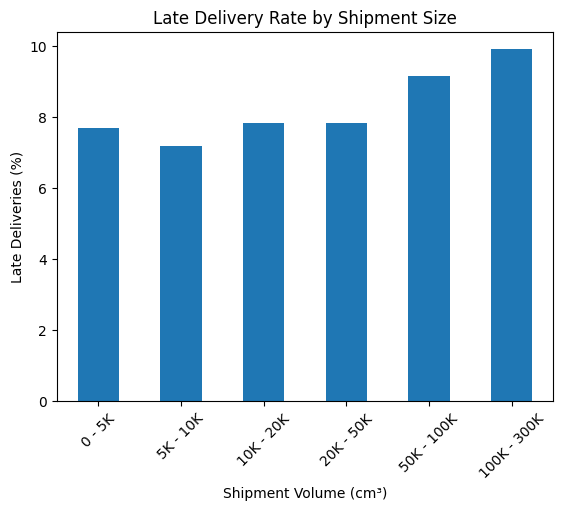

In [120]:
size_delay.plot(kind="bar")

plt.title("Late Delivery Rate by Shipment Size")
plt.xlabel("Shipment Volume (cm³)")
plt.ylabel("Late Deliveries (%)")
plt.xticks(rotation=45)
plt.show()

#### ✅ What is the average delay duration, and how does it vary by state?

##### Average

In [125]:
# creat the delay_days col to store delay days
delivered["delay_days"] = (delivered_day - delivered["order_estimated_delivery_date"]).dt.days
delivered["delay_days"].head()

0    -8
1    -6
2   -18
3   -13
4   -10
Name: delay_days, dtype: int64

In [126]:
late = delivered[fi1]
late.shape

(6531, 9)

In [127]:
late["delay_days"].mean()

np.float64(10.623028632674934)

##### By state

In [128]:
late_states = pd.merge(late, customers, on="customer_id", how="inner")

In [129]:
by_state = late_states.groupby("customer_state")["delay_days"].agg(["mean"])
by_state.sort_values("mean", ascending=False)

,mean
customer_state,
AP,72.500000
RR,36.400000
AM,30.250000
AC,18.666667
SE,16.196078
CE,15.181818
RN,14.477273
RJ,13.522408
PI,13.348485


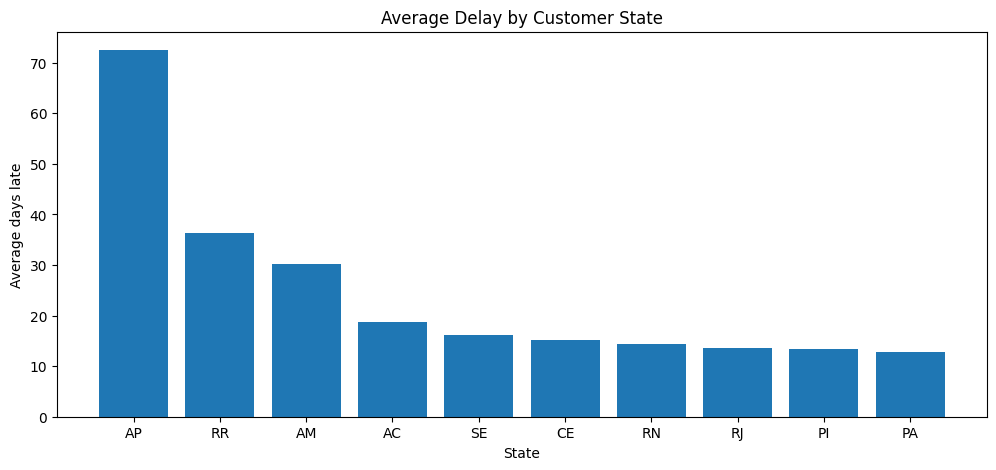

In [130]:
by_state = by_state.sort_values("mean", ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(by_state.index, by_state["mean"])
plt.title("Average Delay by Customer State")
plt.xlabel("State")
plt.ylabel("Average days late")
plt.show();

##### By product category

In [131]:
late_products = pd.merge(late, order_items, on="order_id", how="inner")
late_products = pd.merge(late_products, products, on="product_id", how="inner")
late_products = pd.merge(late_products, translation, on="product_category_name", how="inner")

In [132]:
by_category = late_products.groupby("product_category_name_english")["delay_days"].agg(["mean"])
by_category.sort_values("mean", ascending=False).head(10)

,mean
product_category_name_english,
home_appliances_2,21.928571
food_drink,18.454545
music,18.000000
furniture_mattress_and_upholstery,15.200000
signaling_and_security,14.750000
home_comfort_2,14.500000
air_conditioning,14.363636
drinks,14.125000
home_confort,12.975000


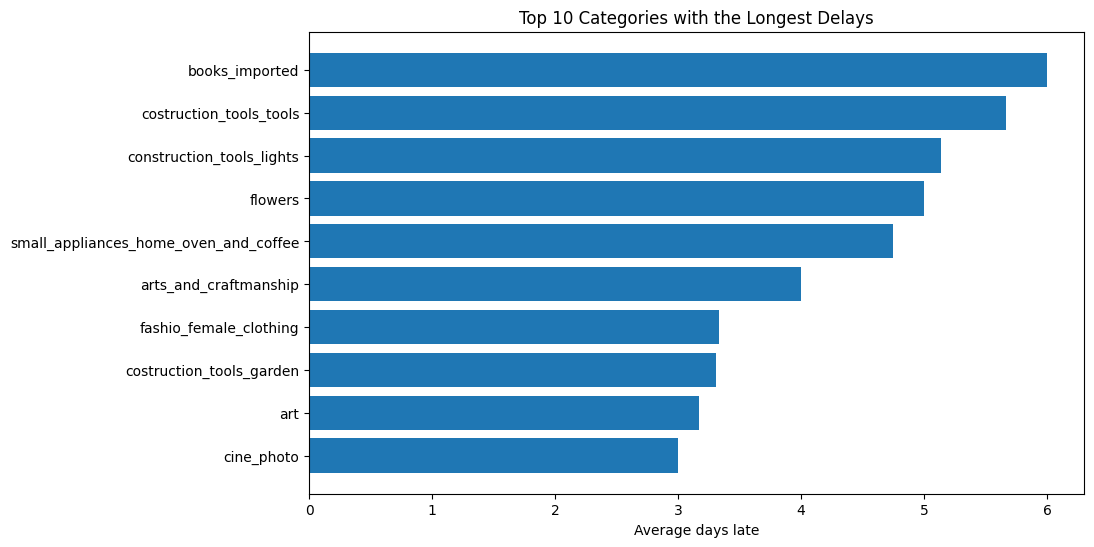

In [133]:
top10_categories = by_category.sort_values(by="mean").head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10_categories.index, top10_categories["mean"])
plt.title("Top 10 Categories with the Longest Delays")
plt.xlabel("Average days late")
plt.show()

##### By order size

In [134]:
delivery_product["DELAY DAYS"] = (
    delivery_product["order_delivered_customer_date"] -
    delivery_product["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [135]:
late_orders = delivery_product[delivery_product["DELAY DAYS"] > 0]

In [136]:
size_avg_delay = (late_orders.groupby("SIZE GROUP", observed=True)["DELAY DAYS"].mean())
size_avg_delay

SIZE GROUP
0 - 5K          8.848722
5K - 10K        9.340173
10K - 20K      10.694308
20K - 50K       8.965566
50K - 100K     10.932052
100K - 300K    11.306990
Name: DELAY DAYS, dtype: float64

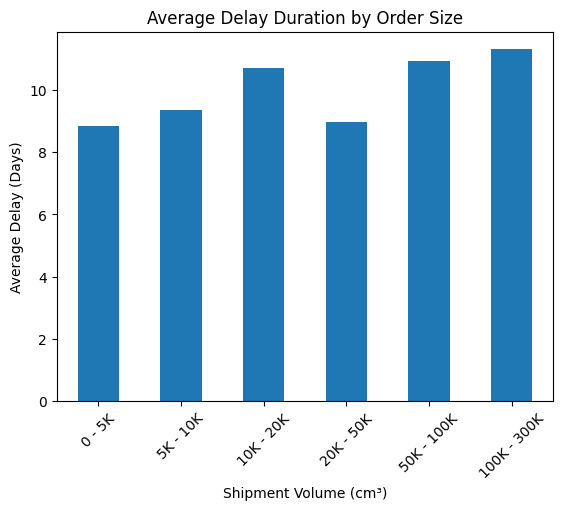

In [137]:
size_avg_delay.plot(kind="bar")

plt.title("Average Delay Duration by Order Size")
plt.xlabel("Shipment Volume (cm³)")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=45)
plt.show()